# CFM Auction Volume Prediction



## 1. Imports and configuration


In [91]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 180)

RANDOM_STATE = 42
N_SPLITS = 5
TOP_FEATURES_FOR_REPORT = 40

USE_ENGINEERED_FEATURES = True
CLIP_PREDICTIONS = True
CLIP_LOWER_Q = 0.001
CLIP_UPPER_Q = 0.999

SUBMISSION_NAME = "submission_cfm_lgbm_residual.csv"

In [92]:
candidate_project_dirs = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "quant_training" / "CFM_auction_volume",
]

for candidate in candidate_project_dirs:
    if (candidate / "data" / "raw").exists():
        PROJECT_DIR = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not locate CFM_auction_volume/data/raw from the current working directory")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
REPORTS_DIR = PROJECT_DIR / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SUBMISSION_PATH = PROCESSED_DIR / SUBMISSION_NAME
PROJECT_DIR

PosixPath('/Users/anasfail/Desktop/Quant_FAIL/quant_training/CFM_auction_volume')

## 2. Load raw data



In [93]:
def find_one(pattern: str) -> Path:
    matches = sorted(RAW_DIR.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No file matching {pattern!r} in {RAW_DIR}")
    if len(matches) > 1:
        print(f"Several files match {pattern!r}; using {matches[0].name}")
    return matches[0]

X_TRAIN_PATH = find_one("input_training*.csv.gz")
X_TEST_PATH = find_one("input_test*.csv.gz")
Y_TRAIN_PATH = find_one("output_training*.csv")

print("X_train:", X_TRAIN_PATH.name)
print("X_test :", X_TEST_PATH.name)
print("y_train:", Y_TRAIN_PATH.name)

X_train: input_training (2).csv.gz
X_test : input_test (2).csv.gz
y_train: output_training_IxKGwDV (1).csv


In [94]:
X_train = pd.read_csv(X_TRAIN_PATH, index_col="ID")
X_test = pd.read_csv(X_TEST_PATH, index_col="ID")
y_train = pd.read_csv(Y_TRAIN_PATH, index_col="ID")["target"]

assert X_train.index.equals(y_train.index), "Train input and target IDs are not aligned"
assert X_train.columns.equals(X_test.columns), "Train and test columns differ"

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("Train day range:", int(X_train["day"].min()), "->", int(X_train["day"].max()))
print("Test day range :", int(X_test["day"].min()), "->", int(X_test["day"].max()))

X_train.head()

X_train: (684482, 126)
y_train: (684482,)
X_test : (311744, 126)
Train day range: 0 -> 804
Test day range : 805 -> 1151


,pid,day,abs_ret0,abs_ret1,abs_ret2,abs_ret3,abs_ret4,abs_ret5,abs_ret6,abs_ret7,abs_ret8,abs_ret9,abs_ret10,abs_ret11,abs_ret12,abs_ret13,abs_ret14,abs_ret15,abs_ret16,abs_ret17,abs_ret18,abs_ret19,abs_ret20,abs_ret21,abs_ret22,abs_ret23,abs_ret24,abs_ret25,abs_ret26,abs_ret27,abs_ret28,abs_ret29,abs_ret30,abs_ret31,abs_ret32,abs_ret33,abs_ret34,abs_ret35,abs_ret36,abs_ret37,abs_ret38,abs_ret39,abs_ret40,abs_ret41,abs_ret42,abs_ret43,abs_ret44,abs_ret45,abs_ret46,abs_ret47,abs_ret48,abs_ret49,abs_ret50,abs_ret51,abs_ret52,abs_ret53,abs_ret54,abs_ret55,abs_ret56,abs_ret57,abs_ret58,abs_ret59,abs_ret60,rel_vol0,rel_vol1,rel_vol2,rel_vol3,rel_vol4,rel_vol5,rel_vol6,rel_vol7,rel_vol8,rel_vol9,rel_vol10,rel_vol11,rel_vol12,rel_vol13,rel_vol14,rel_vol15,rel_vol16,rel_vol17,rel_vol18,rel_vol19,rel_vol20,rel_vol21,rel_vol22,rel_vol23,rel_vol24,rel_vol25,rel_vol26,rel_vol27,rel_vol28,rel_vol29,rel_vol30,rel_vol31,rel_vol32,rel_vol33,rel_vol34,rel_vol35,rel_vol36,rel_vol37,rel_vol38,rel_vol39,rel_vol40,rel_vol41,rel_vol42,rel_vol43,rel_vol44,rel_vol45,rel_vol46,rel_vol47,rel_vol48,rel_vol49,rel_vol50,rel_vol51,rel_vol52,rel_vol53,rel_vol54,rel_vol55,rel_vol56,rel_vol57,rel_vol58,rel_vol59,rel_vol60,LS,NLV
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
148,360,0,0.000000,0.000000,0.0,0.000000,0.029317,0.000000,0.000000,0.000000,0.000000,0.073260,0.073265,0.0,0.036601,0.102399,0.029261,0.00000,0.073206,0.032942,0.036609,0.000000,0.014641,0.036643,0.0,0.036630,0.007326,0.000000,0.0,0.000000,0.000000,0.000000,0.014656,0.000000,0.000000,0.000000,0.0,0.021989,0.036627,0.018305,0.000000,0.000000,0.014653,0.014664,0.0,0.000000,0.022001,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.014684,0.000000,0.000000,0.000000,0.017012,0.033960,0.010170,0.017610,0.011819,0.008788,0.018882,0.076994,0.023252,0.036693,0.056622,0.063628,0.034104,0.032562,0.023147,0.014878,0.017843,0.027046,0.015799,0.033233,0.010206,0.032214,0.014492,0.019147,0.023043,0.010204,0.015254,0.006455,0.006221,0.007477,0.015452,0.005510,0.014621,0.004915,0.009695,0.014404,0.011438,0.005018,0.003520,0.006112,0.001629,0.007395,0.007272,0.017971,0.007965,0.003240,0.008937,0.008786,0.009677,0.008480,0.011040,0.004054,0.009431,0.004521,0.015771,0.009462,0.012697,0.019507,0.005101,0.010654,0.006971,-2.307230,0.646580
149,360,1,0.000000,0.000000,0.0,0.022056,0.000000,0.036711,0.000000,0.000000,0.036767,0.000000,0.058949,0.0,0.014700,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.014743,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.014802,0.014818,0.000000,0.000000,0.022168,0.000000,0.0,0.000000,0.051764,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.029533,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.029451,0.000000,0.022073,0.022078,0.014647,0.003738,0.016063,0.004187,0.013652,0.068420,0.062320,0.128265,0.088308,0.015140,0.081926,0.003656,0.030442,0.009072,0.014110,0.008326,0.003758,0.004072,0.004967,0.042592,0.009573,0.007778,0.009379,0.007153,0.010241,0.005084,0.010341,0.009629,0.008034,0.012606,0.022932,0.002855,0.010928,0.004953,0.001122,0.007357,0.032969,0.004212,0.004200,0.002189,0.004183,0.000931,0.000753,0.008522,0.011424,0.042281,0.003987,0.002132,0.003802,0.003952,0.009427,0.017466,0.023188,0.008817,0.006589,0.005276,0.011648,0.011829,0.015558,0.001788,0.005251,-2.263960,0.487708
150,360,2,0.000000,0.000000,0.0,0.000000,0.022267,0.000000,0.029678,0.014831,0.048146,0.092654,0.000000,NaN,0.000000,0.051902,0.000000,0.02227,0.000000,0.118457,0.059084,0.000000,0.000000,0.014806,0.0,0.022166,0.000000,0.000000,0.0,0.000000,0.029588,0.044418,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.011091,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.014778,0.081355,0.0,0.014796,0.000000,0.022189,0.007399,0.000000,0.0000

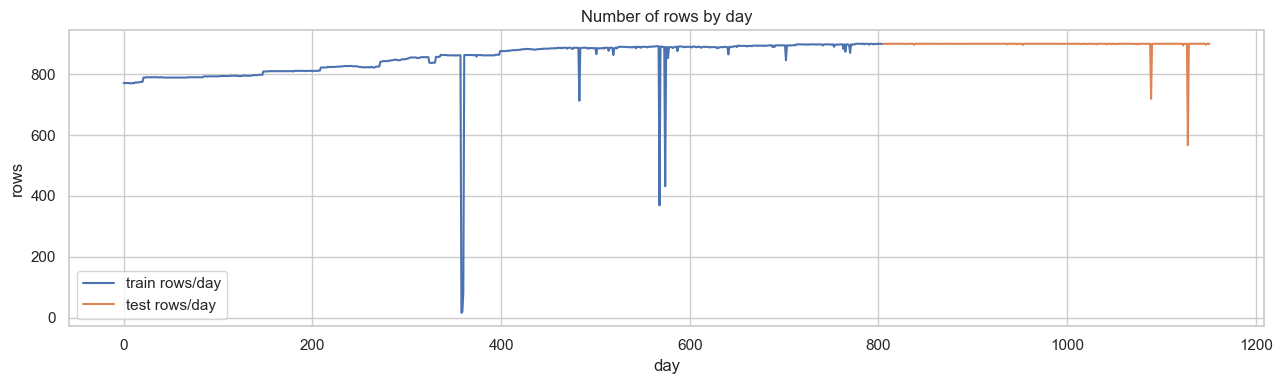

In [95]:
fig, ax = plt.subplots(figsize=(13, 4))
X_train.groupby("day").size().plot(ax=ax, label="train rows/day")
X_test.groupby("day").size().plot(ax=ax, label="test rows/day")
ax.set_title("Number of rows by day")
ax.set_xlabel("day")
ax.set_ylabel("rows")
ax.legend()
plt.tight_layout()

## 3. Schema and data quality checks

In [96]:
N_PERIODS = 61

ID_FEATURES = ["pid", "day"]
ABS_RET_FEATURES = [f"abs_ret{i}" for i in range(N_PERIODS)]
REL_VOL_FEATURES = [f"rel_vol{i}" for i in range(N_PERIODS)]
UNDISCLOSED_FEATURES = ["LS", "NLV"]
BASE_FEATURES = ID_FEATURES + ABS_RET_FEATURES + REL_VOL_FEATURES + UNDISCLOSED_FEATURES

missing_expected = sorted(set(BASE_FEATURES) - set(X_train.columns))
extra_columns = sorted(set(X_train.columns) - set(BASE_FEATURES))

print("Expected feature count:", len(BASE_FEATURES))
print("Actual feature count  :", X_train.shape[1])
print("Missing expected     :", missing_expected)
print("Extra columns        :", extra_columns)

assert not missing_expected, "Some expected challenge features are missing"

Expected feature count: 126
Actual feature count  : 126
Missing expected     : []
Extra columns        : []


In [97]:
quality_report = pd.DataFrame({
    "missing_train": X_train.isna().mean(),
    "missing_test": X_test.isna().mean(),
    "nunique_train": X_train.nunique(dropna=False),
})
quality_report["constant_train"] = quality_report["nunique_train"] <= 1
quality_report.sort_values(["missing_train", "missing_test"], ascending=False).head(20)

,missing_train,missing_test,nunique_train,constant_train
abs_ret45,0.062612,0.047712,152682,False
rel_vol45,0.062612,0.047712,641626,False
abs_ret44,0.060628,0.047857,154042,False
rel_vol44,0.060628,0.047857,642984,False
abs_ret47,0.059723,0.049688,153251,False
rel_vol47,0.059723,0.049688,643604,False
abs_ret43,0.059166,0.046673,154770,False
rel_vol43,0.059166,0.046673,643985,False
abs_ret42,0.058178,0.048286,155843,False
rel_vol42,0.058178,0.048286,644661,False


,train_rel_vol_sum,test_rel_vol_sum
count,6.844820e+05,3.117440e+05
mean,1.000000e+00,1.000000e+00
std,2.629818e-15,2.643098e-15
min,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.000000e+00
75%,1.000000e+00,1.000000e+00
max,1.000000e+00,1.000000e+00


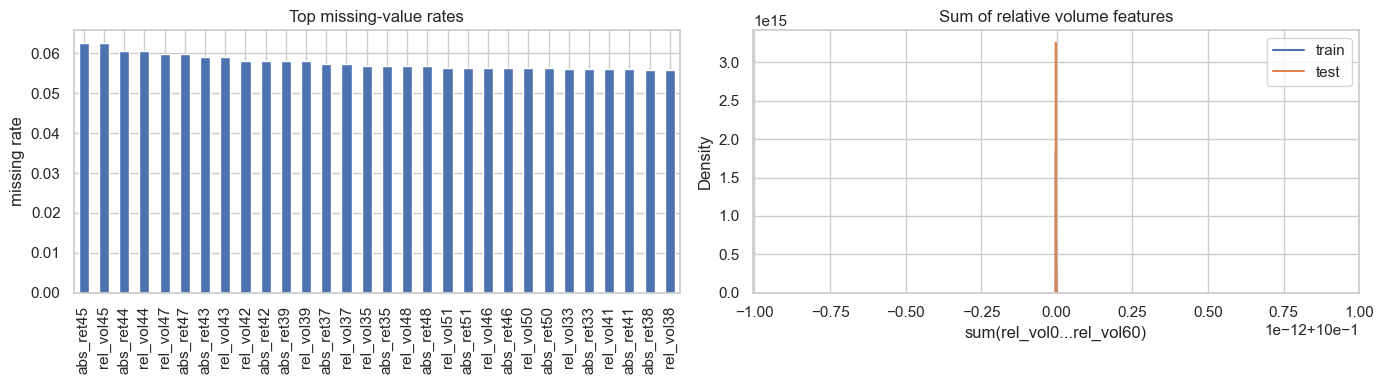

In [98]:
rel_vol_sum_train = X_train[REL_VOL_FEATURES].sum(axis=1)
rel_vol_sum_test = X_test[REL_VOL_FEATURES].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
quality_report[["missing_train", "missing_test"]].max(axis=1).sort_values(ascending=False).head(30).plot(kind="bar", ax=axes[0])
axes[0].set_title("Top missing-value rates")
axes[0].set_ylabel("missing rate")

sns.kdeplot(rel_vol_sum_train, label="train", ax=axes[1])
sns.kdeplot(rel_vol_sum_test, label="test", ax=axes[1])
axes[1].set_title("Sum of relative volume features")
axes[1].set_xlabel("sum(rel_vol0...rel_vol60)")
axes[1].legend()

plt.tight_layout()

pd.DataFrame({
    "train_rel_vol_sum": rel_vol_sum_train.describe(),
    "test_rel_vol_sum": rel_vol_sum_test.describe(),
})

## 4. Exploratory visualizations

count    684482.000000
mean         -1.958691
std           0.909245
min          -7.137686
0.1%         -5.040133
0.5%         -4.459365
1%           -4.205076
5%           -3.489601
50%          -1.948804
95%          -0.493399
99%           0.311658
99.5%         0.656138
99.9%         1.469958
max           3.580919
Name: target, dtype: float64

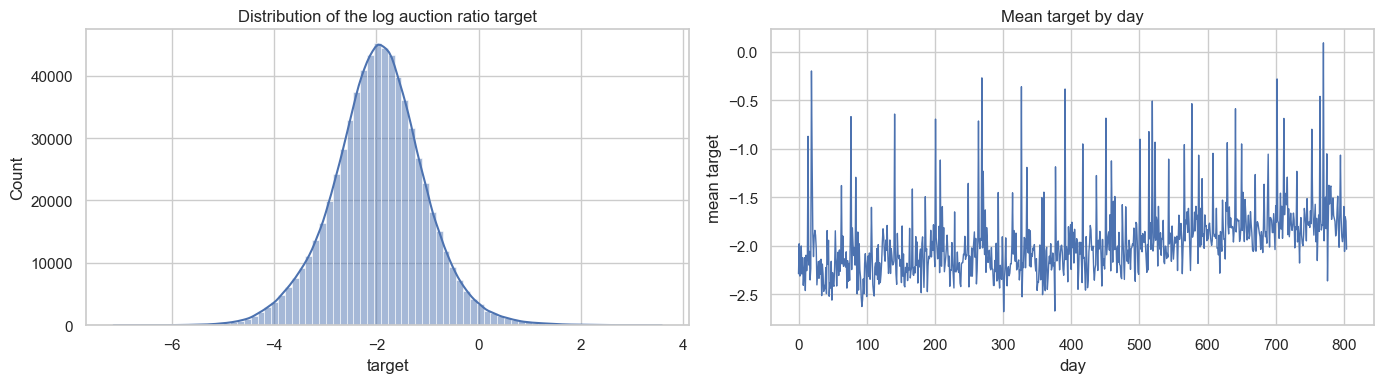

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(y_train, bins=80, kde=True, ax=axes[0])
axes[0].set_title("Distribution of the log auction ratio target")
axes[0].set_xlabel("target")

daily_target = y_train.groupby(X_train["day"]).mean()
daily_target.plot(ax=axes[1], lw=1)
axes[1].set_title("Mean target by day")
axes[1].set_xlabel("day")
axes[1].set_ylabel("mean target")

plt.tight_layout()

y_train.describe(percentiles=[0.001, 0.005, 0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 0.999])

,target_mean,target_std,n_obs
pid,,,
724,-3.980051,0.620891,801
584,-3.905698,0.609634,802
467,-3.763608,0.749345,715
171,-3.755210,0.736512,801
249,-3.702382,0.914474,469


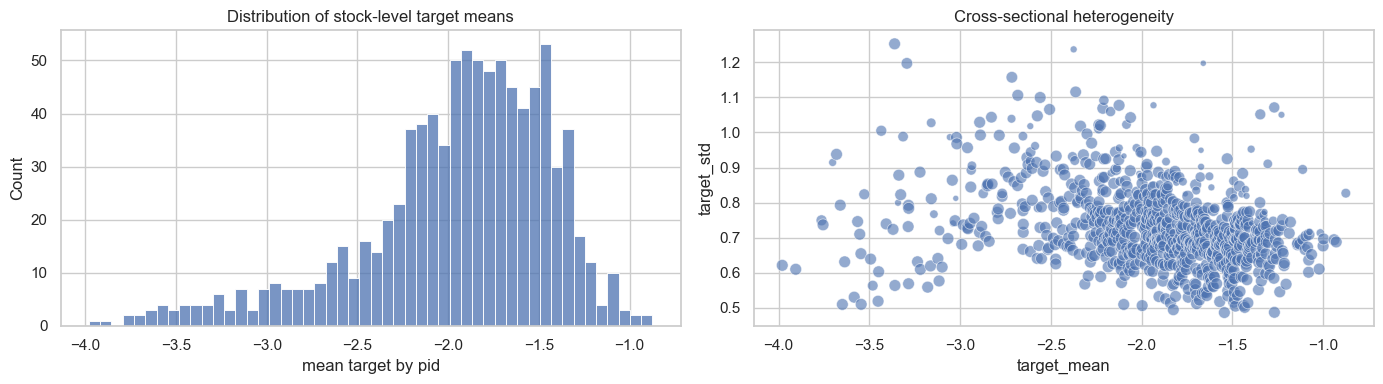

In [100]:
pid_stats = pd.DataFrame({
    "target_mean": y_train.groupby(X_train["pid"]).mean(),
    "target_std": y_train.groupby(X_train["pid"]).std(),
    "n_obs": y_train.groupby(X_train["pid"]).size(),
}).sort_values("target_mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(pid_stats["target_mean"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of stock-level target means")
axes[0].set_xlabel("mean target by pid")

sns.scatterplot(data=pid_stats, x="target_mean", y="target_std", size="n_obs", alpha=0.6, ax=axes[1], legend=False)
axes[1].set_title("Cross-sectional heterogeneity")

plt.tight_layout()
pid_stats.head()

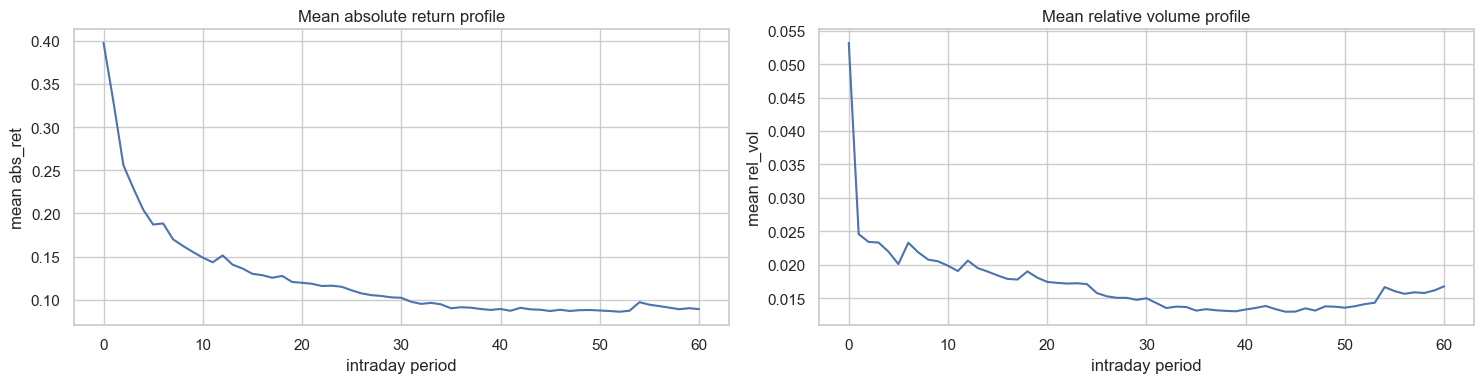

In [101]:
mean_abs_ret = X_train[ABS_RET_FEATURES].mean()
mean_rel_vol = X_train[REL_VOL_FEATURES].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(range(N_PERIODS), mean_abs_ret.values)
axes[0].set_title("Mean absolute return profile")
axes[0].set_xlabel("intraday period")
axes[0].set_ylabel("mean abs_ret")

axes[1].plot(range(N_PERIODS), mean_rel_vol.values)
axes[1].set_title("Mean relative volume profile")
axes[1].set_xlabel("intraday period")
axes[1].set_ylabel("mean rel_vol")

plt.tight_layout()

## 5. Feature engineering

The benchmark model can run either on raw challenge features only or on these engineered summaries. Toggle `USE_ENGINEERED_FEATURES` in the first cell.

In [102]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    abs_ret = out[ABS_RET_FEATURES]
    rel_vol = out[REL_VOL_FEATURES]

    out["abs_ret_sum"] = abs_ret.sum(axis=1)
    out["abs_ret_mean"] = abs_ret.mean(axis=1)
    out["abs_ret_std"] = abs_ret.std(axis=1)
    out["abs_ret_max"] = abs_ret.max(axis=1)
    out["abs_ret_early_mean"] = abs_ret.iloc[:, :20].mean(axis=1)
    out["abs_ret_mid_mean"] = abs_ret.iloc[:, 20:41].mean(axis=1)
    out["abs_ret_late_mean"] = abs_ret.iloc[:, 41:].mean(axis=1)
    out["abs_ret_late_minus_early"] = out["abs_ret_late_mean"] - out["abs_ret_early_mean"]

    out["rel_vol_sum"] = rel_vol.sum(axis=1)
    out["rel_vol_std"] = rel_vol.std(axis=1)
    out["rel_vol_max"] = rel_vol.max(axis=1)
    out["rel_vol_concentration"] = (rel_vol ** 2).sum(axis=1)
    out["rel_vol_early_share"] = rel_vol.iloc[:, :20].sum(axis=1)
    out["rel_vol_mid_share"] = rel_vol.iloc[:, 20:41].sum(axis=1)
    out["rel_vol_late_share"] = rel_vol.iloc[:, 41:].sum(axis=1)
    out["rel_vol_late_minus_early"] = out["rel_vol_late_share"] - out["rel_vol_early_share"]

    rel_vol_safe = rel_vol.clip(lower=1e-12)
    out["rel_vol_entropy"] = -(rel_vol_safe * np.log(rel_vol_safe)).sum(axis=1)

    weighted_abs_ret = abs_ret.to_numpy() * rel_vol.to_numpy()
    out["volume_weighted_abs_ret"] = weighted_abs_ret.sum(axis=1)
    out["late_volume_weighted_abs_ret"] = weighted_abs_ret[:, 41:].sum(axis=1)

    out["LS_x_NLV"] = out["LS"] * out["NLV"]
    out["abs_ret_sum_x_late_vol"] = out["abs_ret_sum"] * out["rel_vol_late_share"]

    return out

if USE_ENGINEERED_FEATURES:
    X_train_model = add_features(X_train)
    X_test_model = add_features(X_test)
else:
    X_train_model = X_train.copy()
    X_test_model = X_test.copy()

print("X_train_model:", X_train_model.shape)
print("X_test_model :", X_test_model.shape)

X_train_model: (684482, 147)
X_test_model : (311744, 147)


### Checkpoint plot: engineered summary features

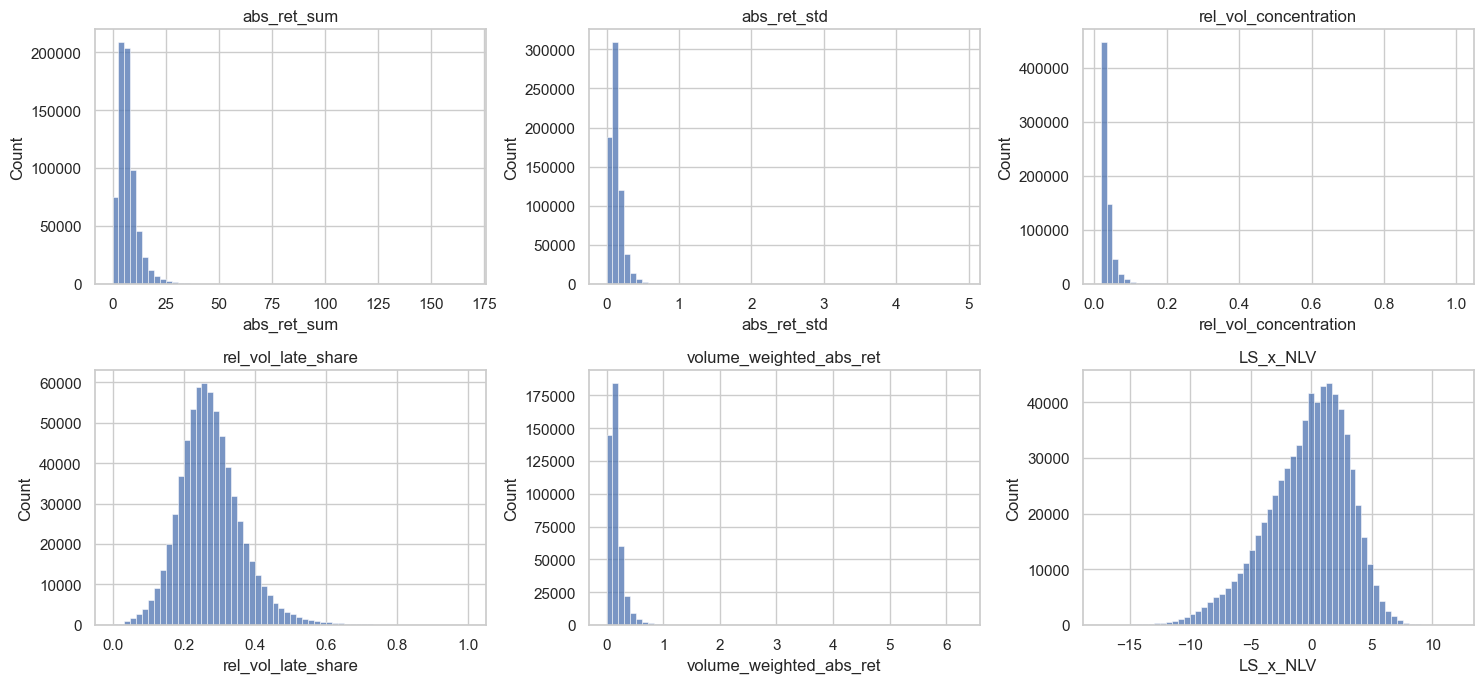

In [103]:
engineered_preview_cols = [
    c for c in [
        "abs_ret_sum",
        "abs_ret_std",
        "rel_vol_concentration",
        "rel_vol_late_share",
        "volume_weighted_abs_ret",
        "LS_x_NLV",
    ]
    if c in X_train_model.columns
]

if engineered_preview_cols:
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    axes = axes.ravel()
    for ax, col in zip(axes, engineered_preview_cols):
        sns.histplot(X_train_model[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=60, ax=ax)
        ax.set_title(col)
    for ax in axes[len(engineered_preview_cols):]:
        ax.axis("off")
    plt.tight_layout()
else:
    print("No engineered preview columns because USE_ENGINEERED_FEATURES=False")

## 6. Feature selection diagnostics

In [104]:
all_features = list(X_train_model.columns)
missing_rate = X_train_model[all_features].isna().mean()
nunique = X_train_model[all_features].nunique(dropna=False)

dropped_features = sorted(set(missing_rate[missing_rate > 0.98].index) | set(nunique[nunique <= 1].index))
model_features = [f for f in all_features if f not in dropped_features]

linear_features = [f for f in model_features if f != "pid"]
lgbm_features = model_features.copy()

print("Dropped features:", dropped_features)
print("Linear features:", len(linear_features))
print("LightGBM features:", len(lgbm_features))

Dropped features: []
Linear features: 146
LightGBM features: 147


In [105]:
corr_scores = X_train_model[linear_features].corrwith(y_train).abs().sort_values(ascending=False)
corr_table = corr_scores.head(TOP_FEATURES_FOR_REPORT).to_frame("abs_corr_with_target")
corr_table

,abs_corr_with_target
volume_weighted_abs_ret,0.275128
abs_ret_sum,0.261089
NLV,0.260983
abs_ret_mean,0.236298
abs_ret_early_mean,0.222857
abs_ret_mid_mean,0.216295
LS_x_NLV,0.206796
abs_ret_late_mean,0.200741
abs_ret_std,0.187067
abs_ret_max,0.174773


In [106]:
mi_sample_size = min(80_000, len(X_train_model))
mi_sample = X_train_model.sample(mi_sample_size, random_state=RANDOM_STATE) if len(X_train_model) > mi_sample_size else X_train_model
mi_y = y_train.loc[mi_sample.index]

mi_input = mi_sample[linear_features].replace([np.inf, -np.inf], np.nan).fillna(0)
mi_scores = pd.Series(
    mutual_info_regression(mi_input, mi_y, random_state=RANDOM_STATE),
    index=linear_features,
).sort_values(ascending=False)
mi_table = mi_scores.head(TOP_FEATURES_FOR_REPORT).to_frame("mutual_information")
mi_table

,mutual_information
volume_weighted_abs_ret,0.065365
NLV,0.063632
abs_ret_sum,0.060962
abs_ret_mean,0.052351
LS_x_NLV,0.045496
abs_ret_early_mean,0.044103
day,0.037001
abs_ret_mid_mean,0.035795
abs_ret_sum_x_late_vol,0.035734
abs_ret_late_mean,0.034738


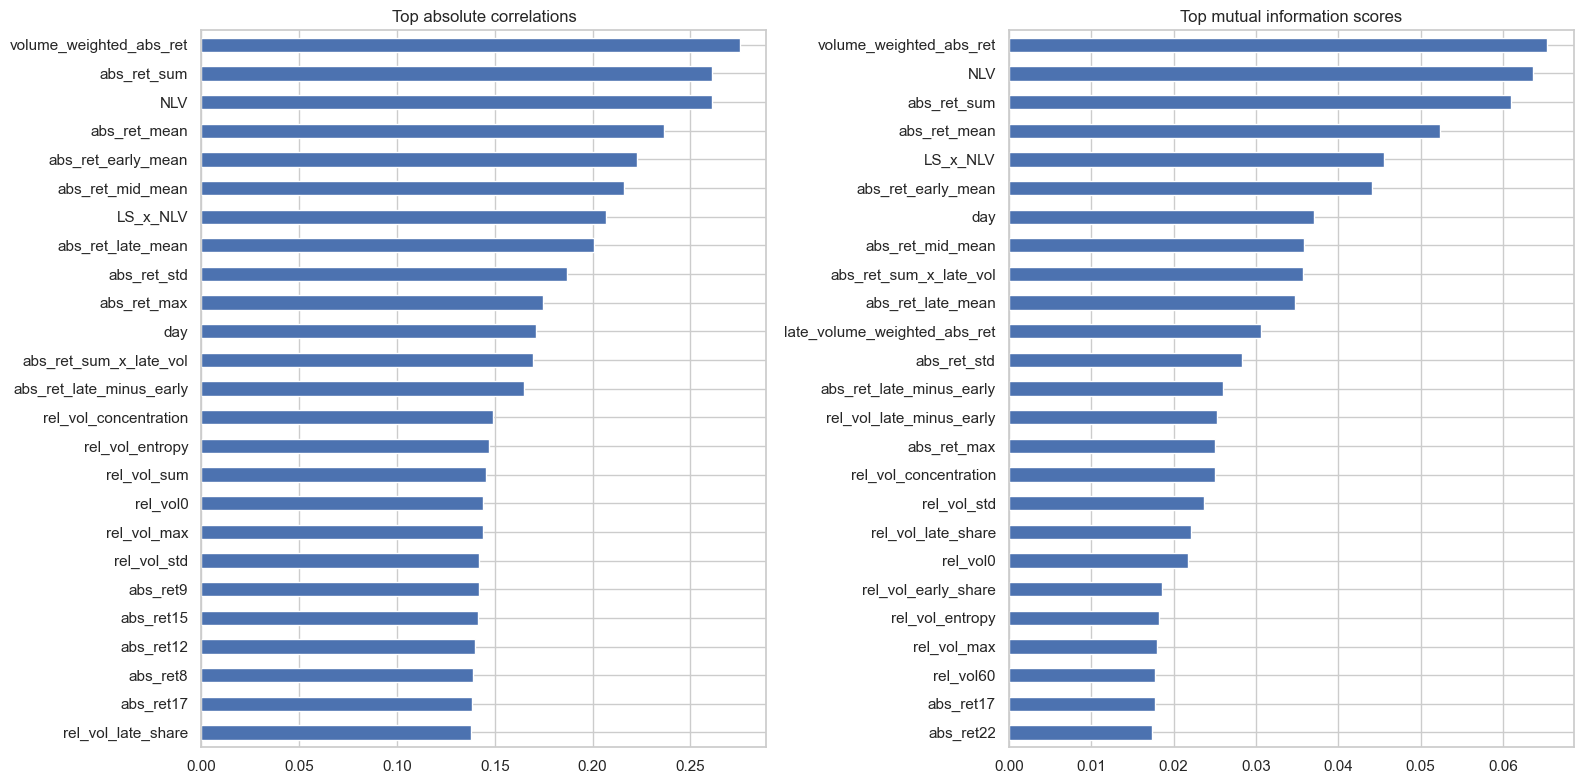

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
corr_table.sort_values("abs_corr_with_target").tail(25).plot(kind="barh", ax=axes[0], legend=False)
axes[0].set_title("Top absolute correlations")

mi_table.sort_values("mutual_information").tail(25).plot(kind="barh", ax=axes[1], legend=False)
axes[1].set_title("Top mutual information scores")

plt.tight_layout()

## 7. Benchmark model: linear baseline plus LightGBM residuals

The challenge benchmark is a two-stage model:

1. zero-impute missing values and fit a linear model without `pid`,
2. train LightGBM on the linear-model residuals using all model features, including `pid`,
3. add both predictions.

In [108]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def make_linear_model():
    return make_pipeline(
        SimpleImputer(strategy="constant", fill_value=0),
        StandardScaler(with_mean=False),
        Ridge(alpha=1.0, random_state=RANDOM_STATE),
    )


def make_lgbm_model(n_estimators=5000):
    return lgb.LGBMRegressor(
        objective="regression",
        metric="rmse",
        n_estimators=n_estimators,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=80,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )


def chronological_splits_by_day(X: pd.DataFrame, n_splits: int):
    unique_days = np.array(sorted(X["day"].unique()))
    n_splits = min(n_splits, max(2, len(unique_days) - 1))
    splitter = TimeSeriesSplit(n_splits=n_splits)
    for train_day_idx, val_day_idx in splitter.split(unique_days):
        train_days = set(unique_days[train_day_idx])
        val_days = set(unique_days[val_day_idx])
        train_idx = X.index[X["day"].isin(train_days)]
        val_idx = X.index[X["day"].isin(val_days)]
        yield train_idx, val_idx

In [109]:
X_lgbm = X_train_model[lgbm_features].copy()
X_lgbm["pid"] = X_lgbm["pid"].astype("category")

cv_rows = []
oof_pred = pd.Series(index=X_train_model.index, dtype=float)
lgbm_models = []

for fold, (train_idx, val_idx) in enumerate(chronological_splits_by_day(X_train_model, N_SPLITS), start=1):
    X_tr = X_train_model.loc[train_idx]
    X_val = X_train_model.loc[val_idx]
    y_tr = y_train.loc[train_idx]
    y_val = y_train.loc[val_idx]

    linear_model = make_linear_model()
    linear_model.fit(X_tr[linear_features], y_tr)

    pred_tr_linear = linear_model.predict(X_tr[linear_features])
    pred_val_linear = linear_model.predict(X_val[linear_features])
    residual_tr = y_tr - pred_tr_linear

    residual_model = make_lgbm_model()
    residual_model.fit(
        X_lgbm.loc[train_idx],
        residual_tr,
        eval_set=[(X_lgbm.loc[val_idx], y_val - pred_val_linear)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)],
    )

    pred_val = pred_val_linear + residual_model.predict(X_lgbm.loc[val_idx])
    oof_pred.loc[val_idx] = pred_val
    lgbm_models.append(residual_model)

    cv_rows.append({
        "fold": fold,
        "train_days": f"{int(X_tr['day'].min())}-{int(X_tr['day'].max())}",
        "val_days": f"{int(X_val['day'].min())}-{int(X_val['day'].max())}",
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "rmse_linear": rmse(y_val, pred_val_linear),
        "rmse_final": rmse(y_val, pred_val),
        "mae_final": mean_absolute_error(y_val, pred_val),
        "r2_final": r2_score(y_val, pred_val),
        "best_iteration": residual_model.best_iteration_,
    })

cv_results = pd.DataFrame(cv_rows)
cv_results

Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.7387
Early stopping, best iteration is:
[73]	valid_0's rmse: 0.737015
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.719692
[200]	valid_0's rmse: 0.71325
[300]	valid_0's rmse: 0.709319
[400]	valid_0's rmse: 0.706606
[500]	valid_0's rmse: 0.704254
[600]	valid_0's rmse: 0.702792
[700]	valid_0's rmse: 0.701767
[800]	valid_0's rmse: 0.701319
[900]	valid_0's rmse: 0.700876
[1000]	valid_0's rmse: 0.700647
[1100]	valid_0's rmse: 0.700141
[1200]	valid_0's rmse: 0.699985
[1300]	valid_0's rmse: 0.70015
Early stopping, best iteration is:
[1206]	valid_0's rmse: 0.699979
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.676038
[200]	valid_0's rmse: 0.667291
[300]	valid_0's rmse: 0.666707
[400]	valid_0's rmse: 0.665054
[500]	valid_0's rmse: 0.664792
[600]	valid_0's rmse: 0.664414
[700]	valid_0's rmse: 0.663772
[800]	valid_0's rmse: 0.66377
E

,fold,train_days,val_days,n_train,n_val,rmse_linear,rmse_final,mae_final,r2_final,best_iteration
0,1,0-134,135-268,106443,109252,0.837960,0.737015,0.574567,0.349194,73
1,2,0-268,269-402,215695,112183,0.830854,0.699979,0.524578,0.417103,1206
2,3,0-402,403-536,327878,118302,0.784744,0.663672,0.509678,0.431446,708
3,4,0-536,537-670,446180,118224,0.752086,0.644795,0.479170,0.428103,174
4,5,0-670,671-804,564404,120078,0.748520,0.660723,0.500503,0.413329,63


In [110]:
cv_summary = cv_results[["rmse_linear", "rmse_final", "mae_final", "r2_final"]].agg(["mean", "std"])
cv_summary

,rmse_linear,rmse_final,mae_final,r2_final
mean,0.790833,0.681237,0.517699,0.407835
std,0.042283,0.037148,0.035797,0.033627


### Cross-validation predictions

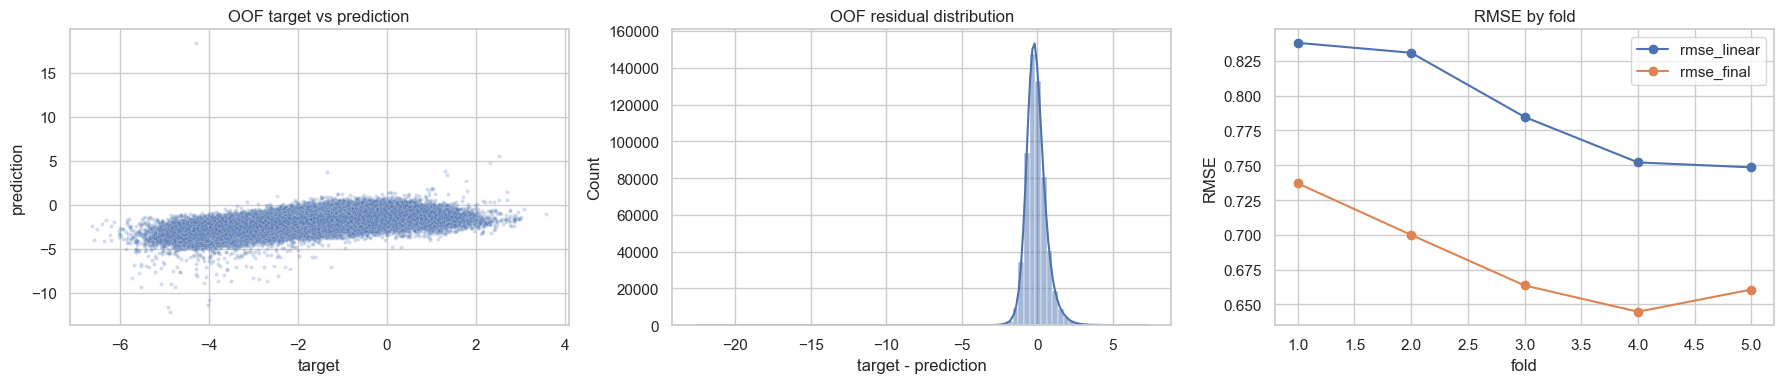

In [111]:
valid_oof = oof_pred.notna()
oof_residuals = y_train.loc[valid_oof] - oof_pred.loc[valid_oof]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.scatterplot(x=y_train.loc[valid_oof], y=oof_pred.loc[valid_oof], s=8, alpha=0.25, ax=axes[0])
axes[0].set_title("OOF target vs prediction")
axes[0].set_xlabel("target")
axes[0].set_ylabel("prediction")

sns.histplot(oof_residuals, bins=80, kde=True, ax=axes[1])
axes[1].set_title("OOF residual distribution")
axes[1].set_xlabel("target - prediction")

cv_results.plot(x="fold", y=["rmse_linear", "rmse_final"], marker="o", ax=axes[2])
axes[2].set_title("RMSE by fold")
axes[2].set_ylabel("RMSE")

plt.tight_layout()

## 8. LightGBM feature importance

In [112]:
importance_frames = []
for fold, model in enumerate(lgbm_models, start=1):
    importance_frames.append(pd.DataFrame({
        "feature": model.feature_name_,
        "gain": model.booster_.feature_importance(importance_type="gain"),
        "split": model.booster_.feature_importance(importance_type="split"),
        "fold": fold,
    }))

feature_importance = (
    pd.concat(importance_frames)
    .groupby("feature", as_index=False)[["gain", "split"]]
    .mean()
    .sort_values("gain", ascending=False)
)

feature_importance.to_csv(REPORTS_DIR / "cfm_lgbm_feature_importance.csv", index=False)
feature_importance.head(TOP_FEATURES_FOR_REPORT)

,feature,gain,split
75,pid,1.025494e+06,6880.8
73,day,1.317466e+05,1614.0
1,LS_x_NLV,2.863800e+04,384.8
2,NLV,2.531014e+04,257.8
76,rel_vol0,1.553579e+04,306.4
71,abs_ret_sum,1.475672e+04,121.0
70,abs_ret_std,6.754264e+03,100.8
140,rel_vol_late_minus_early,6.692764e+03,66.4
72,abs_ret_sum_x_late_vol,4.644401e+03,45.6
139,rel_vol_entropy,4.341721e+03,76.0


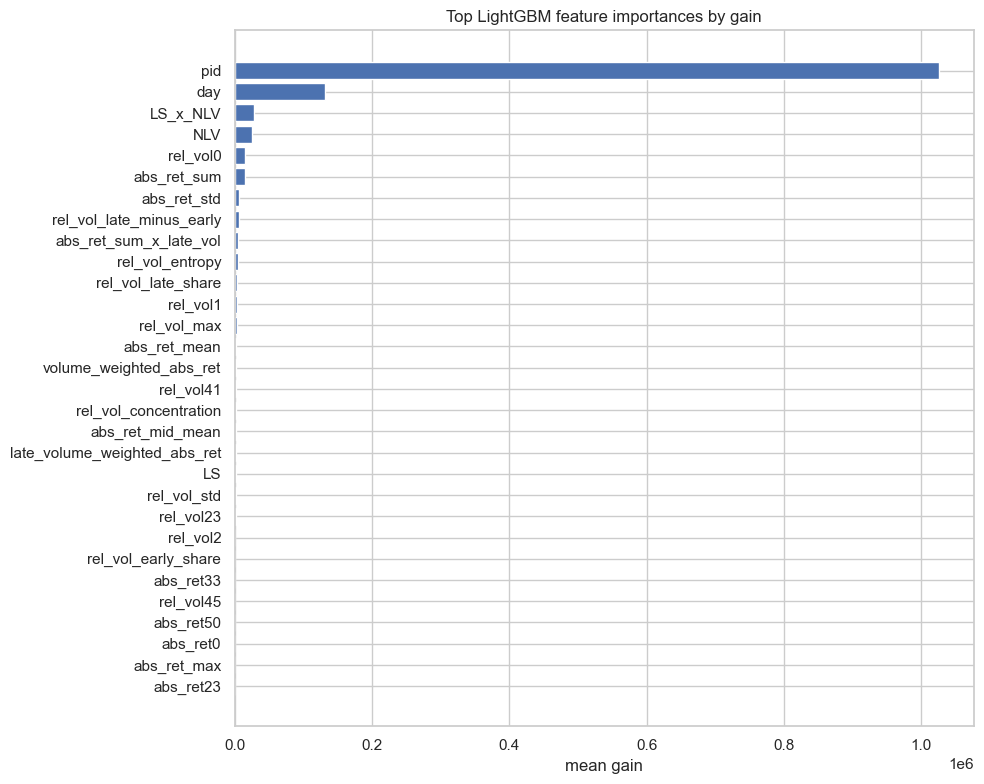

In [113]:
plt.figure(figsize=(10, 8))
top_importance = feature_importance.head(30).sort_values("gain")
plt.barh(top_importance["feature"], top_importance["gain"])
plt.title("Top LightGBM feature importances by gain")
plt.xlabel("mean gain")
plt.tight_layout()

## 9. Final training and submission



In [114]:
best_iterations = [m.best_iteration_ for m in lgbm_models if m.best_iteration_ is not None and m.best_iteration_ > 0]
final_n_estimators = int(np.mean(best_iterations)) if best_iterations else 1500
print("Final n_estimators:", final_n_estimators)

final_linear_model = make_linear_model()
final_linear_model.fit(X_train_model[linear_features], y_train)

train_linear_pred = final_linear_model.predict(X_train_model[linear_features])
train_residual = y_train - train_linear_pred

X_train_lgbm_final = X_train_model[lgbm_features].copy()
X_test_lgbm_final = X_test_model[lgbm_features].copy()
X_train_lgbm_final["pid"] = X_train_lgbm_final["pid"].astype("category")
X_test_lgbm_final["pid"] = X_test_lgbm_final["pid"].astype("category")

final_residual_model = make_lgbm_model(n_estimators=final_n_estimators)
final_residual_model.fit(X_train_lgbm_final, train_residual)

test_linear_pred = final_linear_model.predict(X_test_model[linear_features])
test_residual_pred = final_residual_model.predict(X_test_lgbm_final)
test_pred_raw = test_linear_pred + test_residual_pred

if CLIP_PREDICTIONS:
    lower_clip = y_train.quantile(CLIP_LOWER_Q)
    upper_clip = y_train.quantile(CLIP_UPPER_Q)
    test_pred = np.clip(test_pred_raw, lower_clip, upper_clip)
    print(f"Clipped predictions to [{lower_clip:.4f}, {upper_clip:.4f}]")
else:
    test_pred = test_pred_raw

submission = pd.DataFrame({
    "ID": X_test.index,
    "target": test_pred,
})

prediction_summary = pd.DataFrame({
    "raw_prediction": pd.Series(test_pred_raw).describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]),
    "final_prediction": pd.Series(test_pred).describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]),
    "train_target": y_train.describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]),
})
prediction_summary

Final n_estimators: 444
Clipped predictions to [-5.0401, 1.4700]


,raw_prediction,final_prediction,train_target
count,311744.000000,311744.000000,684482.000000
mean,-1.717200,-1.716873,-1.958691
std,0.607017,0.604307,0.909245
min,-16.553921,-5.040133,-7.137686
0.1%,-4.117390,-4.117390,-5.040133
1%,-3.513226,-3.513226,-4.205076
50%,-1.639198,-1.639198,-1.948804
99%,-0.549898,-0.549898,0.311658
99.9%,-0.074010,-0.074010,1.469958
max,2.409503,1.469958,3.580919


### Final prediction distribution

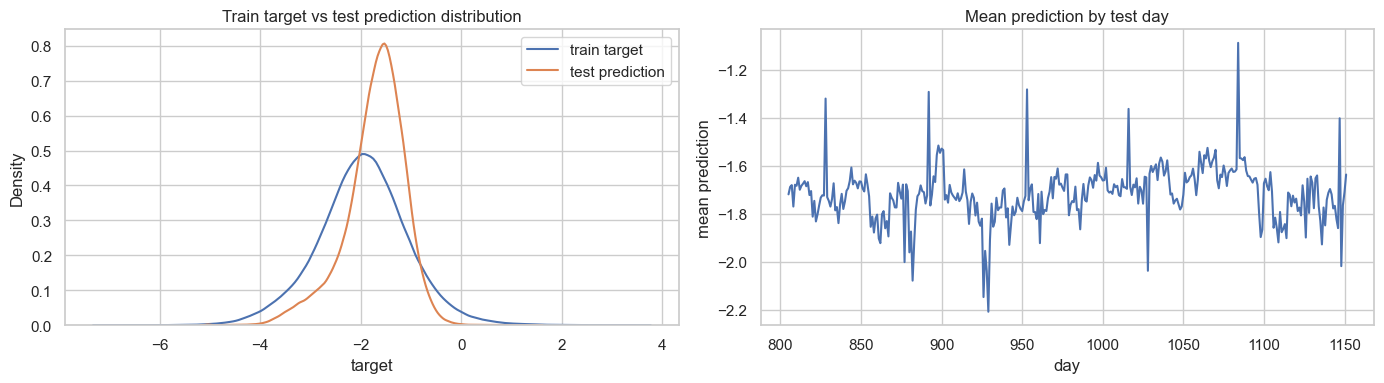

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(y_train, label="train target", ax=axes[0])
sns.kdeplot(test_pred, label="test prediction", ax=axes[0])
axes[0].set_title("Train target vs test prediction distribution")
axes[0].legend()

pd.Series(test_pred, index=X_test.index).groupby(X_test["day"]).mean().plot(ax=axes[1])
axes[1].set_title("Mean prediction by test day")
axes[1].set_xlabel("day")
axes[1].set_ylabel("mean prediction")

plt.tight_layout()

In [116]:
assert list(submission.columns) == ["ID", "target"]
assert len(submission) == len(X_test)
assert submission["ID"].equals(pd.Series(X_test.index, name="ID"))
assert np.isfinite(submission["target"]).all()

submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Saved submission to: {SUBMISSION_PATH}")
submission.head()

Saved submission to: /Users/anasfail/Desktop/Quant_FAIL/quant_training/CFM_auction_volume/data/processed/submission_cfm_lgbm_residual.csv


,ID,target
0,1070752,-1.857356
1,1070753,-1.689415
2,1070754,-1.768978
3,1070755,-1.683290
4,1070756,-1.771381
